In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
titanic = sns.load_dataset('titanic')

features = ['pclass', 'sex', 'fare', 'embarked', 'age']
target = ['survived']

imp_median = SimpleImputer(strategy = 'median')
titanic[['age']] = imp_median.fit_transform(titanic[['age']])

imp_freq = SimpleImputer(strategy = 'most_frequent')
titanic[['embarked']] = imp_freq.fit_transform(titanic[['embarked']])

le = LabelEncoder()

titanic['sex'] = le.fit_transform(titanic['sex'])
titanic['embarked'] = le.fit_transform(titanic['embarked'])

X = titanic[features]
Y = titanic[target]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 42
)

In [4]:
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)

Y_pred_test = model.predict(X_test)
Y_pred_train = model.predict(X_train)

print("Training Accuracy : ", accuracy_score(Y_train, Y_pred_train)*100, '%')
print("Testing Accuracy : ", accuracy_score(Y_test, Y_pred_test)*100, '%')

Training Accuracy :  97.75280898876404 %
Testing Accuracy :  76.53631284916202 %


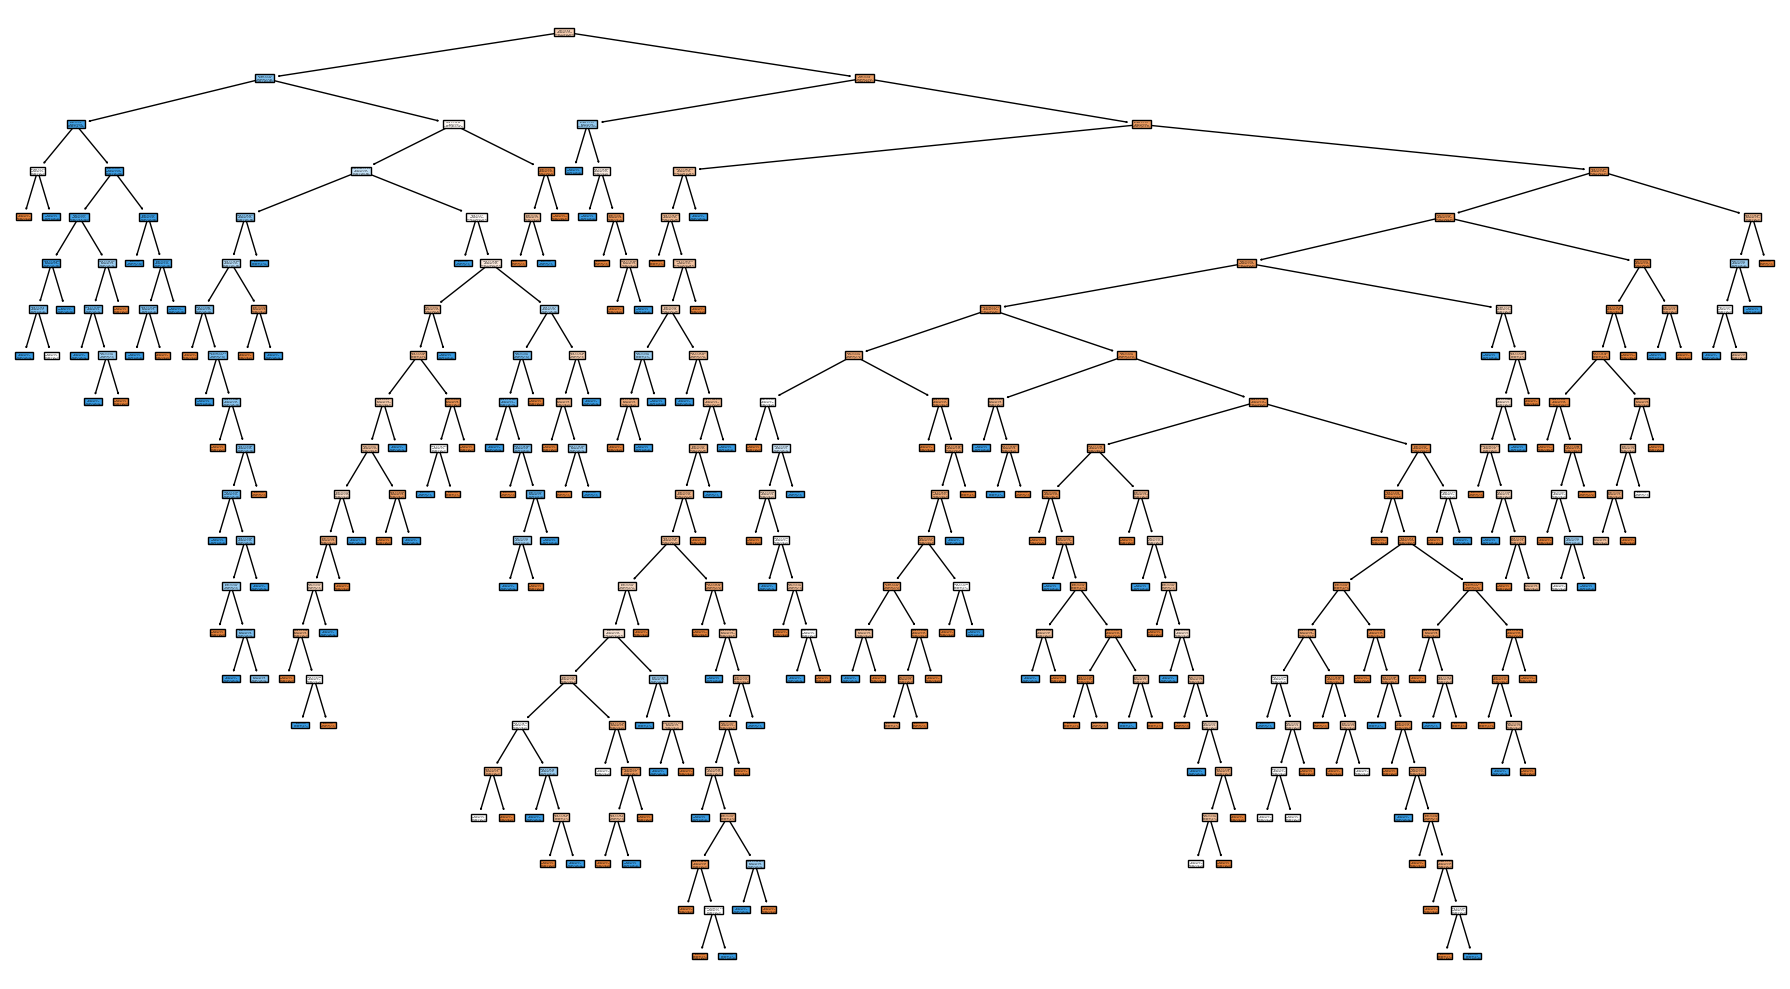

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize = (18, 10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ['Died', 'Survived'],
    filled = True
)

plt.tight_layout()
plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 501,
    oob_score = True
)

rf.fit(X_train, Y_train)

Y_pred = rf.predict(X_test)

print('OOB score: ', rf.oob_score_)
print('testing accuracy: ', accuracy_score(Y_test, Y_pred))

C:\Users\Suraj\Pictures\ML_learn\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


OOB score:  0.7991573033707865
testing accuracy:  0.7932960893854749


In [8]:
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)

bagging.fit(X_train, Y_train)
Y_pred = bagging.predict(X_test)

print('testing accuracy: ', accuracy_score(Y_test, Y_pred))

C:\Users\Suraj\Pictures\ML_learn\Lib\site-packages\sklearn\ensemble\_bagging.py:930: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


testing accuracy:  0.7988826815642458
